# Demo Random Forest classification and regression

In [2]:
# We import some of our usual libraries at this top level.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from ISLP import load_data
import shap
import seaborn as sns

/Users/andrearaaschou/courses/BERN01/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load the data for this demo.
# Metadata can be found at https://intro-stat-learning.github.io/ISLP/datasets/Carseats.html
carseats = load_data('Carseats')
carseats.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


# Data inspection

We will start with inspecting our data. This can easily be done with the .describe() method of pandas dataframes.

After this we will use plotting features in pandas and seaborn to get a better understanding of the data. You are welcome to add cells with additional plots that you are interested in.

In [4]:
carseats.describe()

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,7.496325,124.975000,68.657500,6.635000,264.840000,115.795000,53.322500,13.900000
std,2.824115,15.334512,27.986037,6.650364,147.376436,23.676664,16.200297,2.620528
min,0.000000,77.000000,21.000000,0.000000,10.000000,24.000000,25.000000,10.000000
25%,5.390000,115.000000,42.750000,0.000000,139.000000,100.000000,39.750000,12.000000
50%,7.490000,125.000000,69.000000,5.000000,272.000000,117.000000,54.500000,14.000000
75%,9.320000,135.000000,91.000000,12.000000,398.500000,131.000000,66.000000,16.000000
max,16.270000,175.000000,120.000000,29.000000,509.000000,191.000000,80.000000,18.000000


In [5]:
# Inspect categorical variables
carseats['ShelveLoc'].value_counts()

ShelveLoc
Medium    219
Bad        96
Good       85
Name: count, dtype: int64

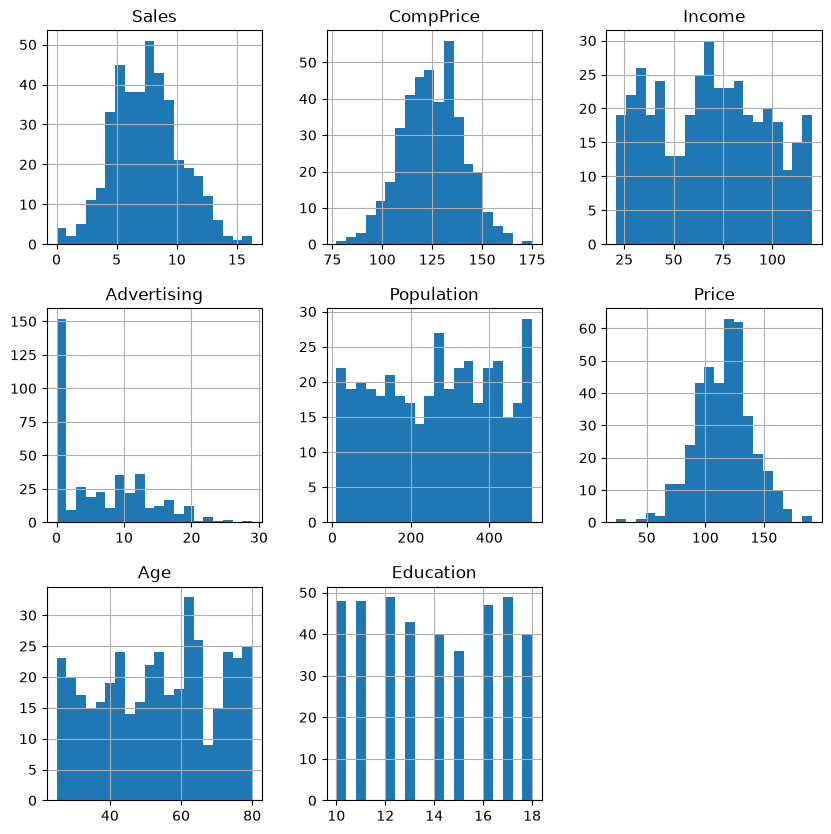

In [8]:
# Look at distributions of numerical values
carseats.hist(figsize=(10, 10), bins=20)
plt.show()

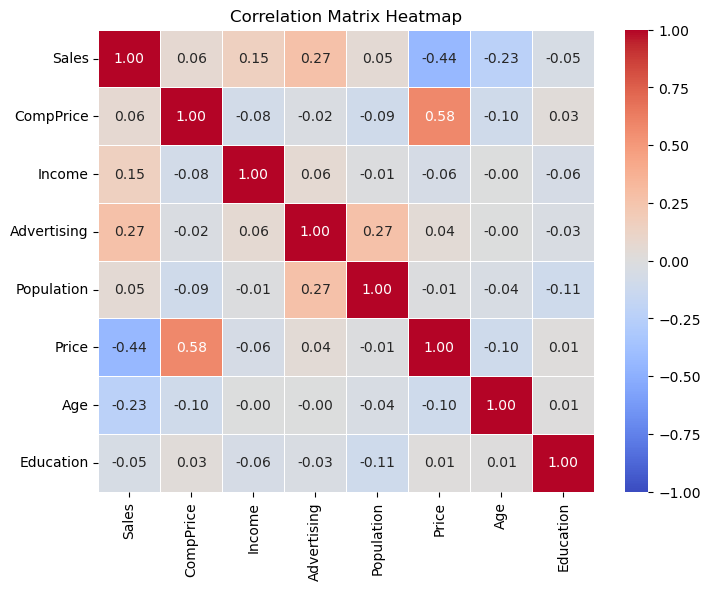

In [21]:
# Plot a correlation matrix
NUMERIC_COLUMNS = ['Sales',	'CompPrice', 'Income', 'Advertising', 'Population', 'Price', 'Age',	'Education']
correlation_matrix = carseats[NUMERIC_COLUMNS].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)

plt.title('Correlation Matrix Heatmap')
plt.show()

# Data transformations

We will need to do a few transformations to the data before we can use it in a random forest classifier.

First, we will create the binary labels from the continuous 'Sales' data, we will call this 'Sales_bin' and use a cutoff at about half the data volume (see histogram above). 

Second, we will encode our string variables into numeric categories. This is done by Scikit-learn's OrdinalEncoder and ColumnTransformer. 

Third, we will split the data into train and test datasets.

In [6]:
# Make binary classes from the sales data to train a random forest classifier on
classifier_data = carseats.copy()
classifier_data['Sales_bin'] = np.where(classifier_data.Sales > 8, 'High', 'Low')
classifier_data.drop('Sales', axis=1, inplace=True)
classifier_data.head()

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,Sales_bin
0,138,73,11,276,120,Bad,42,17,Yes,Yes,High
1,111,48,16,260,83,Good,65,10,Yes,Yes,High
2,113,35,10,269,80,Medium,59,12,Yes,Yes,High
3,117,100,4,466,97,Medium,55,14,Yes,Yes,Low
4,141,64,3,340,128,Bad,38,13,Yes,No,Low


In [7]:
# Encode categoric variables
CATEGORIC_LABELS = ['ShelveLoc', 'Urban', 'US', 'Sales_bin']
encoder = ColumnTransformer([
    ('ord', OrdinalEncoder(), CATEGORIC_LABELS),
], remainder='passthrough')

encoded_data = encoder.fit_transform(classifier_data, )

df_encoded = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out())

df_encoded.head()

,ord__ShelveLoc,ord__Urban,ord__US,ord__Sales_bin,remainder__CompPrice,remainder__Income,remainder__Advertising,remainder__Population,remainder__Price,remainder__Age,remainder__Education
0,0.0,1.0,1.0,0.0,138.0,73.0,11.0,276.0,120.0,42.0,17.0
1,1.0,1.0,1.0,0.0,111.0,48.0,16.0,260.0,83.0,65.0,10.0
2,2.0,1.0,1.0,0.0,113.0,35.0,10.0,269.0,80.0,59.0,12.0
3,2.0,1.0,1.0,1.0,117.0,100.0,4.0,466.0,97.0,55.0,14.0
4,0.0,1.0,0.0,1.0,141.0,64.0,3.0,340.0,128.0,38.0,13.0


In [8]:
# Create train, test and validation datasets
feature_names_rename = {n: n.split('__')[1] for n in encoder.get_feature_names_out()} # Make a bit nicer feature names
df_encoded = df_encoded.rename(columns=feature_names_rename)

y = df_encoded.pop('Sales_bin') # Get the target feature
X_train, X_test, y_train, y_test = train_test_split(df_encoded, y, random_state=42, test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, random_state=42, test_size=0.2, )

X_train

,ShelveLoc,Urban,US,CompPrice,Income,Advertising,Population,Price,Age,Education
179,2.0,1.0,1.0,144.0,25.0,3.0,70.0,116.0,77.0,18.0
270,1.0,1.0,0.0,119.0,26.0,0.0,284.0,89.0,26.0,10.0
323,2.0,1.0,1.0,107.0,105.0,18.0,428.0,103.0,34.0,12.0
399,1.0,1.0,1.0,134.0,37.0,0.0,27.0,120.0,49.0,16.0
40,0.0,0.0,0.0,119.0,98.0,0.0,18.0,126.0,73.0,17.0
...,...,...,...,...,...,...,...,...,...,...
221,2.0,1.0,0.0,124.0,44.0,0.0,125.0,107.0,80.0,11.0
333,2.0,1.0,1.0,136.0,60.0,7.0,303.0,147.0,41.0,10.0
324,0.0,1.0,1.0,136.0,65.0,4.0,133.0,150.0,53.0,13.0
315,1.0,1.0,1.0,131.0,21.0,8.0,220.0,171.0,29.0,14.0


## Fitting Classification Trees
We first use classification trees to analyze the Carseats data set.
We use RandomForestClassifier to fit a binary classification tree in order to predict High using all variables but Sales.

We will then use some helpfull functions in Scikit-learn for evaluating our model.

In [9]:
bin_class = RandomForestClassifier(random_state=1)
bin_class.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstra

In [152]:
score_rfc_train = accuracy_score(y_train, bin_class.predict(X_train))
score_rfc_test = accuracy_score(y_test, bin_class.predict(X_test))
print('Accuracy of RandomForestClassifier on train data: {:.4f}'.format(score_rfc_train))
print('Accuracy of RandomForestClassifier on test data: {:.4f}'.format(score_rfc_test))

Accuracy of RandomForestClassifier on train data: 1.0000
Accuracy of RandomForestClassifier on test data: 0.7500


In [10]:
print("\nClassification Report:")
print(classification_report(y_train, bin_class.predict(X_train)))


Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       100
         1.0       1.00      1.00      1.00       156

    accuracy                           1.00       256
   macro avg       1.00      1.00      1.00       256
weighted avg       1.00      1.00      1.00       256



In [11]:
folds = KFold()

score_cv_train = cross_val_score(bin_class, X_train, y_train, cv=folds)
score_cv_test = cross_val_score(bin_class, X_test, y_test, cv=folds)

print("Average accuracy of RandomForestClassifier on cross validation of train data: %0.4f ( %0.2f)" % (score_cv_train.mean(), score_cv_train.std()))
print("Average accuracy of RandomForestClassifier on cross validation of test data: %0.4f ( %0.2f)" % (score_cv_test.mean(), score_cv_test.std()))

Average accuracy of RandomForestClassifier on cross validation of train data: 0.7540 ( 0.03)
Average accuracy of RandomForestClassifier on cross validation of test data: 0.6625 ( 0.08)


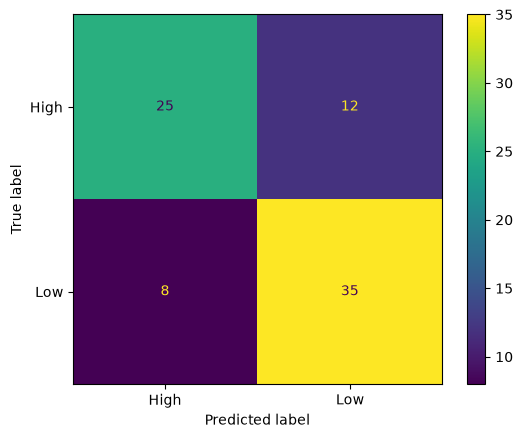

In [12]:
ConfusionMatrixDisplay.from_estimator(
    bin_class, X_test, y_test, display_labels=['High', 'Low'], 
)
plt.show()

# Play around!

You have now successfully trained a random forest binary classifier. Go ahead and play around and see if you can improve it!

Ideas to try out is, whether it gets better by trying out some other different features (are all necessary?). You stratify the train/test splits, transform features, etc. 


When you are done we will try a bit more formal way of finding good hyperparameters on the model, namely grid search

In [ ]:
# Hyperparameter tuning
folds = KFold()

kfold5 = KFold(5, random_state=1, shuffle=True)
n_depths_range = np.arange(1, 20, 2, dtype=np.int16)
n_estimators_range = np.arange(10, 200, 20, dtype=np.int16) # CV number of trees (estimators) 10, 20, ..., 100

params = {
    'max_depth': n_depths_range, # let's tune for only one parameters to save running time
    'n_estimators': n_estimators_range,
     }

rfc_gscv = GridSearchCV(bin_class, param_grid = params, scoring = "accuracy",
                             cv = kfold5)
# Fit the model
model_rfc = rfc_gscv.fit(X_train, y_train)

# Model best estimator
max_depths=model_rfc.best_estimator_.get_params()["max_depth"]
max_trees= model_rfc.best_estimator_.get_params()["n_estimators"]
max_cvs= rfc_gscv.best_score_
print("Max Depth: ", max_depths)
print("Max Trees: ",max_trees)
print("Max CV: ",max_cvs)


Max Depth:  7
Max Trees:  190
Max CV:  0.8202865761689291


In [ ]:
# Get the best model
best_class = model_rfc.best_estimator_

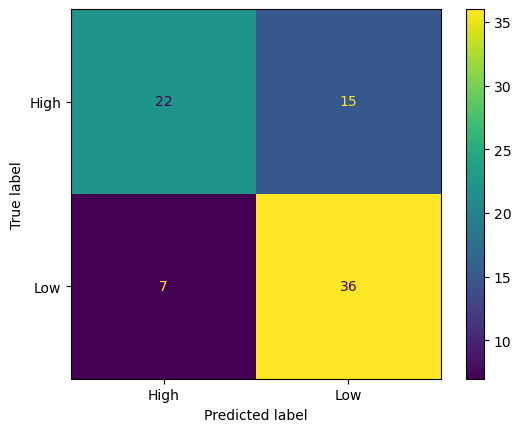

In [ ]:
# Confusion matrices are great for visualizing the performance of a classification model.
# They show the counts of true positive, true negative, false positive, and false negative predictions
ConfusionMatrixDisplay.from_estimator(
    best_class, X_test, y_test, display_labels=['High', 'Low'], 
)
plt.show()

In [192]:
score_rfc_train = accuracy_score(y_train, best_class.predict(X_train))
score_rfc_test = accuracy_score(y_test, best_class.predict(X_test))
print('Accuracy of RandomForestClassifier on train data: {:.4f}'.format(score_rfc_train))
print('Accuracy of RandomForestClassifier on test data: {:.4f}'.format(score_rfc_test))

Accuracy of RandomForestClassifier on train data: 0.9961
Accuracy of RandomForestClassifier on test data: 0.7250


In [ ]:
print("\nClassification Report training data:")
print(classification_report(y_train, best_class.predict(X_train)))

In [ ]:
print("\nClassification Report test data:")
print(classification_report(y_test, best_class.predict(X_test)))

In [ ]:
# Explaining the results

In [193]:
feature_imp = pd.DataFrame(
    {'importance':best_class.feature_importances_},
    index=X_train.columns)
feature_imp.sort_values(by='importance', ascending=False)

,importance
Price,0.266888
Age,0.152384
Advertising,0.145011
CompPrice,0.105090
Population,0.088816
ShelveLoc,0.084449
Income,0.081872
Education,0.044781
Urban,0.016715
US,0.013994


In [194]:
explainer = shap.Explainer(best_class.predict, X_test)
shap_values = explainer(X_test)

ExactExplainer explainer: 81it [00:11,  1.00it/s]                                                                                                                         


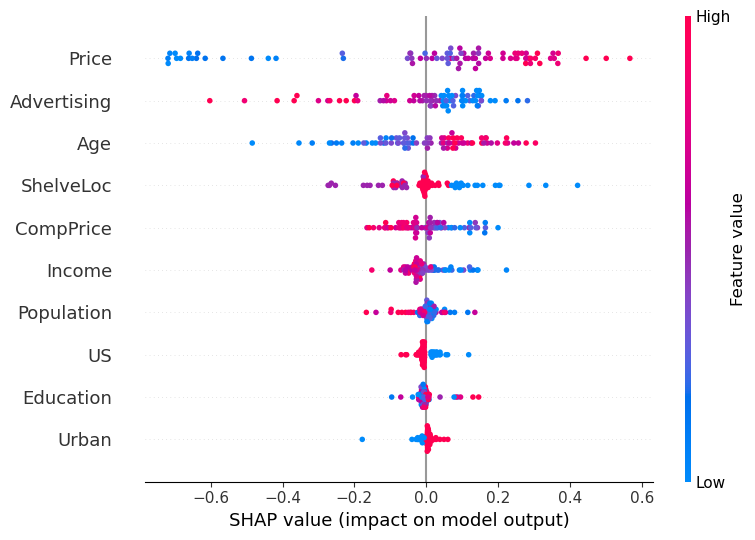

In [195]:
shap.summary_plot(shap_values)

# Random Forest Regression

Here we apply random forests to the data, using the RandomForestRegressor() from the sklearn.ensemble package. The steps are similar to those for classification trees, however, this time we have the continous variables Sales from the Carseats dataset.

We will use the same encodings as before, except the split in high and low sales. Also, we will create new train and test datasets where the Sales data is included.

In [170]:
# Training a random forest regressor

sales = carseats['Sales'].copy()
# Take the encoded data and the sales to predict the sales prices
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(df_encoded, sales, test_size=0.2, random_state=42)


In [171]:
reg_class = RandomForestRegressor(random_state=42)

reg_class.fit(X_reg_train, y_reg_train)


RandomForestRegressor(random_state=42)

In [176]:
pred_train = reg_class.predict(X_reg_train)
pred_test = reg_class.predict(X_reg_test)

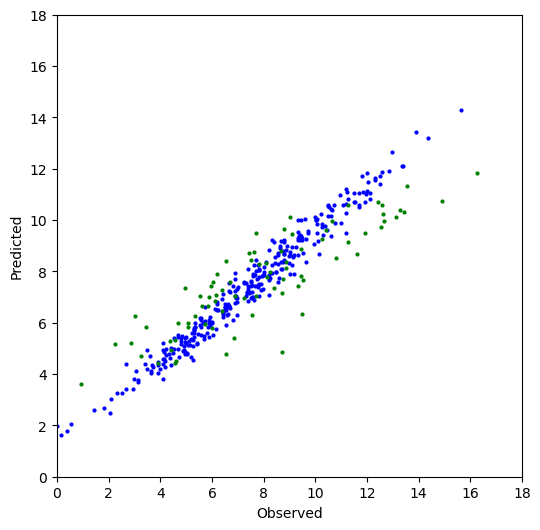

In [182]:
fig, ax = plt.subplots(figsize=(6,6))

ax.scatter(y_reg_train, pred_train, c='blue', s=4)
ax.scatter(y_reg_test, pred_test, c='green', s=4)
ax.set_xlabel('Observed')
ax.set_ylabel('Predicted')
ax.set_xlim(0, 18)
ax.set_ylim(0, 18)
plt.show()

In [185]:
score_reg_train = reg_class.score(X_reg_train, y_reg_train)
score_reg_test = reg_class.score(X_reg_test, y_reg_test)
print('Accuracy of RandomForestRegressor on train data: {:.4f}'.format(score_reg_train))
print('Accuracy of RandomForestRegressor on test data: {:.4f}'.format(score_reg_test))
scores_reg_val = cross_val_score(reg_class, X_reg_train, y_reg_train, cv=KFold())
print("Accuracy RandomForestRegressor on cross validation: %0.4f ( %0.2f)" % (scores_reg_val.mean(), scores_reg_val.std()))

Accuracy of RandomForestRegressor on train data: 0.9531
Accuracy of RandomForestRegressor on test data: 0.6820
Accuracy RandomForestRegressor on cross validation: 0.5796 ( 0.05)
